In [34]:
import pandas as pd
import numpy as np
import sys 
import os 

from sklearn import set_config
from lifelines.statistics import logrank_test
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sklearn.model_selection import train_test_split
from typing import Tuple
from sklearn.model_selection import GroupKFold
set_config(display="text")  # displays text representation of estimators

from sksurv.util import Surv
sys.path.append(os.path.abspath("../../"))
from src.utils.ConvertTextToCsv import TextToCsv
from src.utils.Preprocessing import Preprocessor
from src.utils.plots import Plots
from src.utils.cox_models import Cox_regression, p_values_Cox_regression
%load_ext autoreload
%autoreload 2
%matplotlib inline


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<font size="4">Preprocessing and Plots</font>

In [3]:
pp = Preprocessor()
plots_class = Plots()

In [4]:
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_data = pp.clean_columns_dataset(df_clinical_data)
list_df = pp.total_type_len_type_cancer(df_clinical_data)
df_clinical_data["Tumor-Cancer"] = list_df
df_clinical_data["Tumor-Cancer"].unique()

Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 299 - Total(%) 0.37


array(['<UNK>', 'Luminal A', 'TNBC', 'Luminal B', 'HER2-enriched'],
      dtype=object)

In [5]:
df_mRNA_raw_data = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")


Shape of the CSV: (20440, 819)


<font size="4">Merging the clinical DataSet and mRNA-Seq</font>

In [6]:
df_merged = pp.merge_datasets(df_clinical_data, df_mRNA_raw_data)

In [7]:
comparation_df = df_merged.loc[
    df_merged["Tumor-Cancer"].isin(["Luminal A", "Luminal B", "TNBC", "HER2-enriched"]),
    ["Tumor-Cancer"] + list(df_merged.columns[1:20441])
]
comparation_df["Tumor-Cancer"].unique()

array(['Luminal A', 'TNBC', 'Luminal B', 'HER2-enriched'], dtype=object)

In [8]:
comparation_clean_df = pp.eliminate_zero_genes(comparation_df, "Tumor-Cancer")


Genes before Treshold: 20440
count    20440.000000
mean        74.003816
std        155.561901
min          0.000000
25%          0.000000
50%          0.000000
75%         21.000000
max        519.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 18537


In [9]:
comparation_clean_df.iloc[:, 1:-1]

,0,1,2,3,5,6,7,8,9,13,...,20428,20429,20430,20431,20432,20433,20434,20435,20436,20437
2,4.4426,153.1452,74.7018,0.0000,0.0000,0.9872,5.5944,0.3291,0.3291,1.3163,...,441.5401,810.8597,95.4340,726.6146,1018.8400,57.5895,960.5923,3007.8157,926.3677,1075.4422
6,4.9419,134.8733,63.6488,0.3658,0.0000,0.3658,4.7554,0.0000,0.7316,2.1948,...,354.8240,420.6676,83.7677,2731.4129,834.3850,51.2117,1092.6383,3032.0988,958.3905,718.7929
7,28.8560,1119.1932,166.7192,0.3152,1.8910,0.0000,3.4668,0.0000,0.0000,0.3152,...,1147.9073,1695.2411,69.0199,610.1481,1775.6067,158.5251,1380.7123,591.2386,1798.9285,1335.6445
8,7.6484,119.4760,80.8081,0.3157,0.0000,0.3157,5.6818,0.6313,0.0000,0.6313,...,499.8548,505.0505,60.6061,546.0859,1014.2045,39.4571,1410.0379,4570.0758,1182.4495,1454.8611
10,9.4309,190.5983,140.0949,0.0000,0.0000,0.7297,5.4725,0.0000,0.3648,0.3648,...,738.3984,1306.8223,26.9974,292.2291,1040.4962,241.5177,681.5031,3473.9146,721.9993,1414.0825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
812,7.9343,150.6834,540.4278,1.5649,0.5216,0.0000,6.2598,0.0000,0.0000,0.0000,...,253.9854,294.2097,79.2906,443.9228,1083.4637,40.6886,858.1116,4930.6208,2212.8326,665.6234
813,2.2519,115.3378,338.1985,2.0851,0.0000,2.0851,4.1701,0.0000,0.0000,0.0000,...,314.5788,536.6972,45.4545,747.7064,903.6697,10.4254,634.2786,4163.4696,1251.8766,773.1443
814,1.2603,158.3599,210.7460,0.4173,2.0866,2.5039,2.5039,0.4173,0.0000,0.0000,...,438.4517,482.0031,61.3459,334.2723,933.1247,206.1555,479.0819,6621.1789,649.3479,780.3860
815,5.0428,124.6327,323.1185,0.4507,0.0000,8.1118,5.8585,3.1546,0.0000,9.9144,...,342.3885,465.0744,45.5160,797.6566,1038.3055,13.9703,683.1906,5216.7643,1408.7427,713.3844


In [10]:
print(f"Samples: {comparation_clean_df.shape[0]}, Genes: {comparation_clean_df.shape[1]}")

Samples: 519, Genes: 18538


In [11]:
comparation_clean_df.iloc[:, 1:-1] = np.log2(comparation_clean_df.iloc[:, 1:-1] + 1)


In [26]:
comparation_clean_df.iloc[:, 1:-1]

#print(min(comparation_clean_df[1]))
print(max(comparation_clean_df[comparation_clean_df["Tumor-Cancer"] == "Luminal A"][0]))
print(min(comparation_clean_df[comparation_clean_df["Tumor-Cancer"] == "Luminal A"][0]))

5.004847417769826
0.0


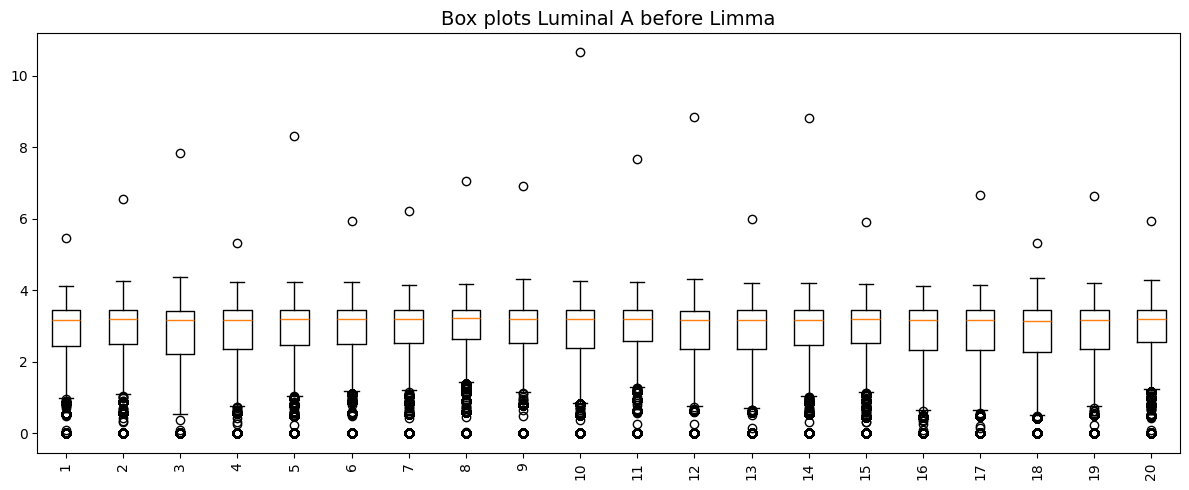

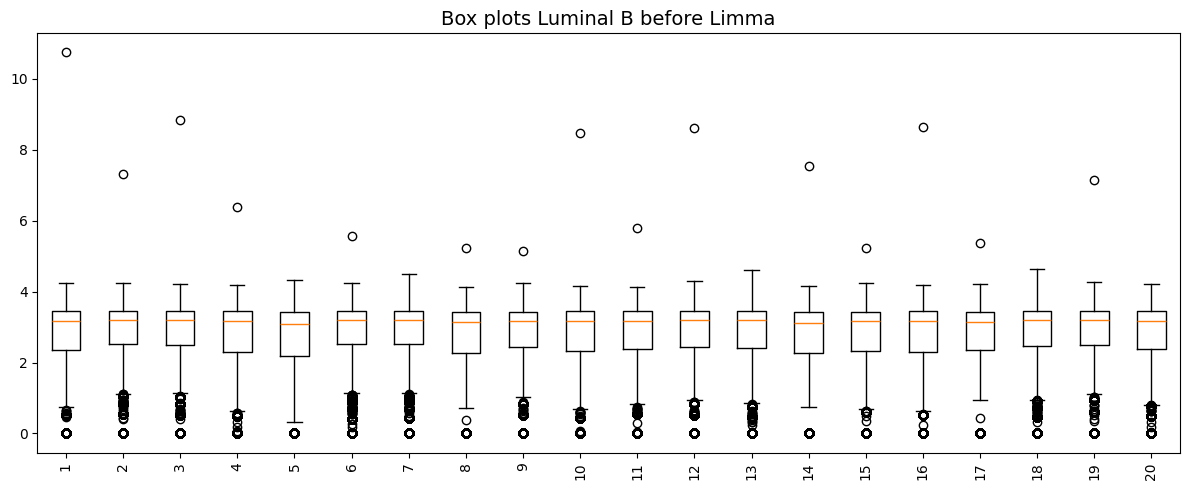

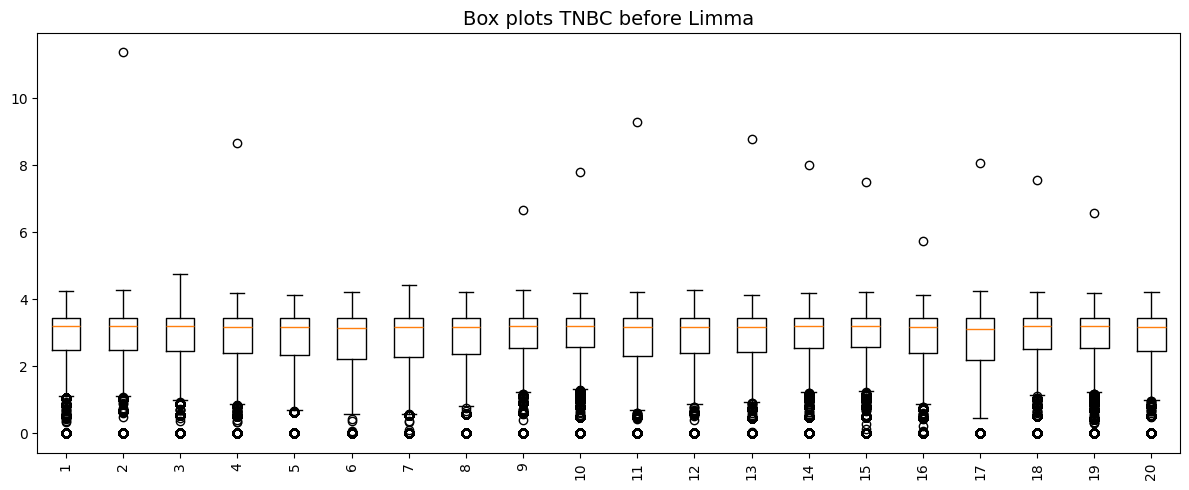

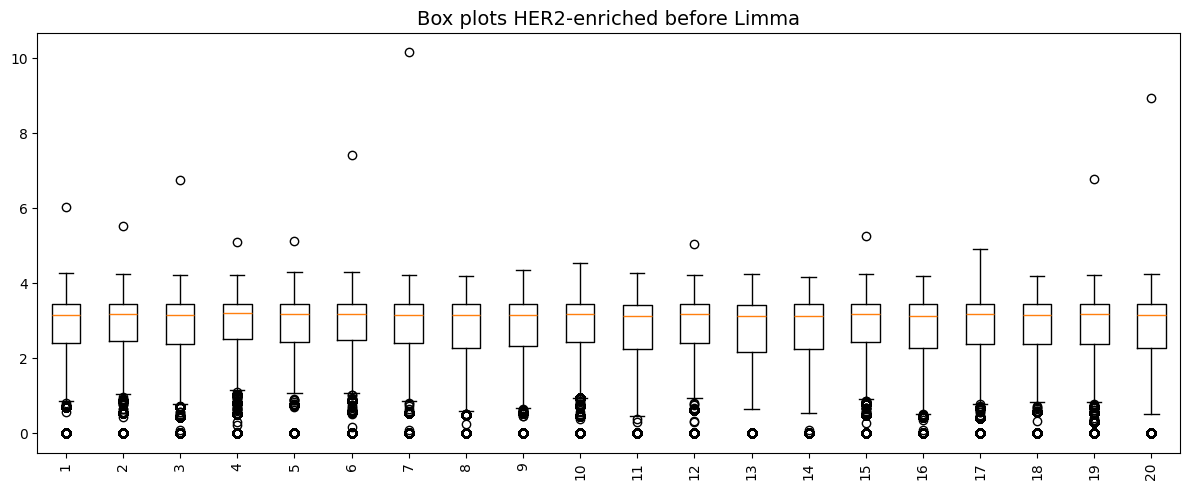

In [27]:
min_range = 1
max_range = 21

plots_class.box_plot(data=comparation_clean_df, title="Box plots Luminal A before Limma",
         type_cancer="Luminal A", range_min=min_range,range_max=max_range)

plots_class.box_plot(data=comparation_clean_df, title="Box plots Luminal B before Limma",
         type_cancer="Luminal B", range_min=min_range,range_max=max_range)

plots_class.box_plot(data=comparation_clean_df, title="Box plots TNBC before Limma",
         type_cancer="TNBC", range_min=min_range,range_max=max_range)

plots_class.box_plot(data=comparation_clean_df, title="Box plots HER2-enriched before Limma",
         type_cancer="HER2-enriched", range_min=min_range,range_max=max_range)


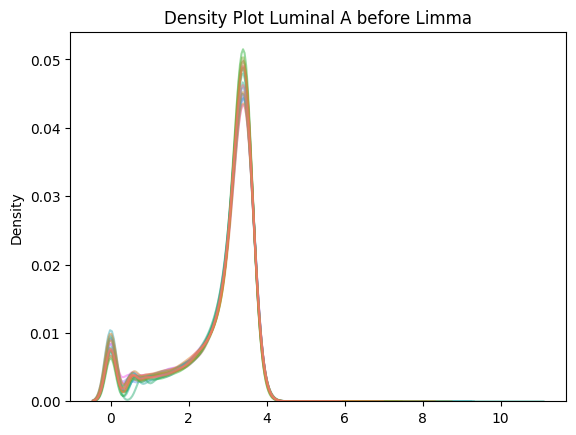

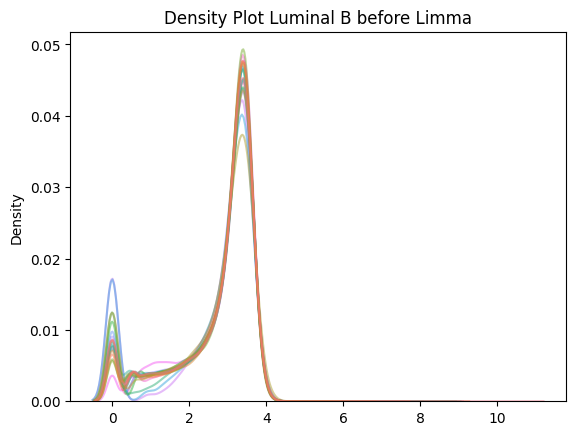

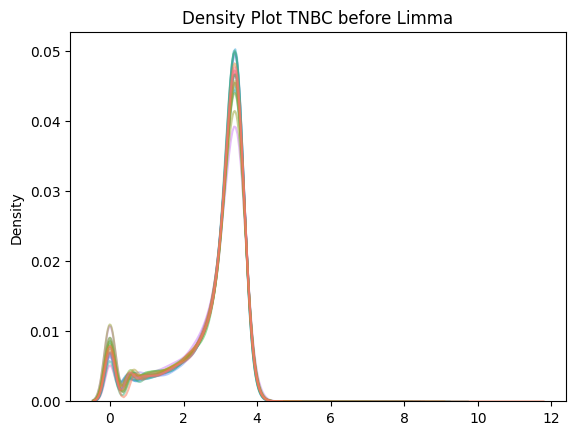

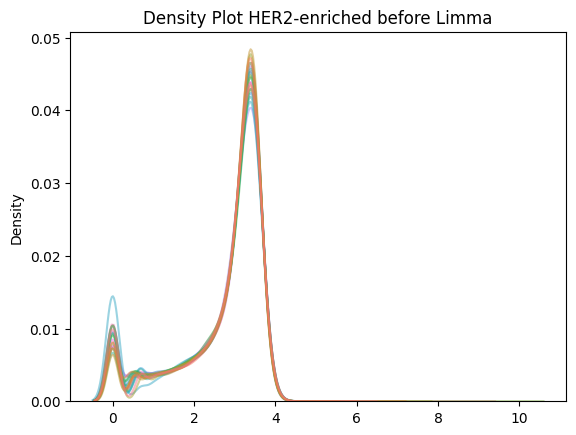

In [28]:

plots_class.density_plot(data=comparation_clean_df, title="Density Plot Luminal A before Limma",
         type_cancer="Luminal A", range_min=min_range,range_max=max_range)

plots_class.density_plot(data=comparation_clean_df, title="Density Plot Luminal B before Limma",
         type_cancer="Luminal B", range_min=min_range,range_max=max_range)

plots_class.density_plot(data=comparation_clean_df, title="Density Plot TNBC before Limma",
         type_cancer="TNBC", range_min=min_range,range_max=max_range)

plots_class.density_plot(data=comparation_clean_df, title="Density Plot HER2-enriched before Limma",
         type_cancer="HER2-enriched", range_min=min_range,range_max=max_range)


In [32]:
plots_class.PCA_4_scatter_matrix_log2(df=comparation_clean_df, cancer_types=["Luminal A", "Luminal B", "TNBC", "HER2-enriched"])

<font size="4">Cox Regression and Multi Cox Regression</font>

In [39]:
def split_data_time_months(df_mRNA: pd.DataFrame, 
                         df_clinical: pd.DataFrame,
                         gene: str,
                         time : int) -> Tuple:
    
    df_single_gene = pp.gene_to_long(df_mRNA, gene)
    
    df_gene_merged = df_single_gene.merge(df_clinical, on="Sample ID", how="inner")
    
    df_gene_merged["Overall Survival (Months)"] = pd.to_numeric(
        df_gene_merged["Overall Survival (Months)"], errors="coerce"
    )
    
    status = df_gene_merged["Overall Survival Status"].astype(str).str.strip()
    df_gene_merged["event"] = status.str.contains("DECEASED", na=False)
    
    df_gene_merged["event_60"] = df_gene_merged["event"].copy()
    df_gene_merged["time_60"] = np.minimum(df_gene_merged["Overall Survival (Months)"], time)
    
    df_gene_merged.loc[
        df_gene_merged["Overall Survival (Months)"] > time, "event_60"
    ] = False
    
    df_gene_merged["expression"] = pd.to_numeric(
        df_gene_merged["expression"], errors="coerce"
    )
    
    df_gene_merged["expression"] = np.log2(df_gene_merged["expression"] +   1)
    
    df_gene_merged = df_gene_merged.dropna(subset=["time_60", "expression"]).copy()
    
    X = df_gene_merged[["expression"]]
    
    Y_surv = Surv.from_dataframe(
        event="event_60",
        time="time_60",
        data=df_gene_merged
    )
    
    return X, Y_surv, df_gene_merged

Genes before Treshold: 818
count     818.000000
mean     2911.273839
std       351.415192
min         0.000000
25%      2709.250000
50%      2866.500000
75%      3078.500000
max      4575.000000
dtype: float64
Threshold (>80% zeros): 16352 samples
After the treshold: 818


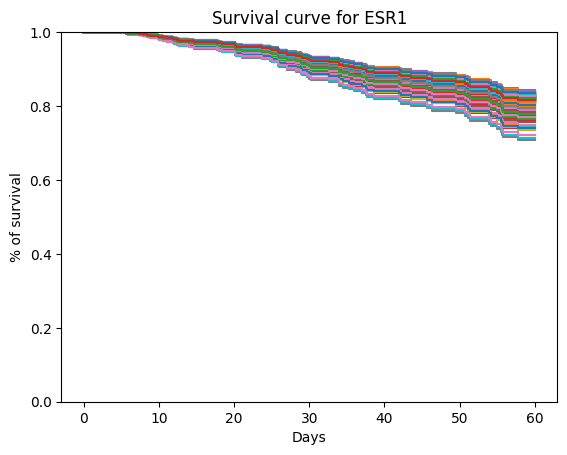

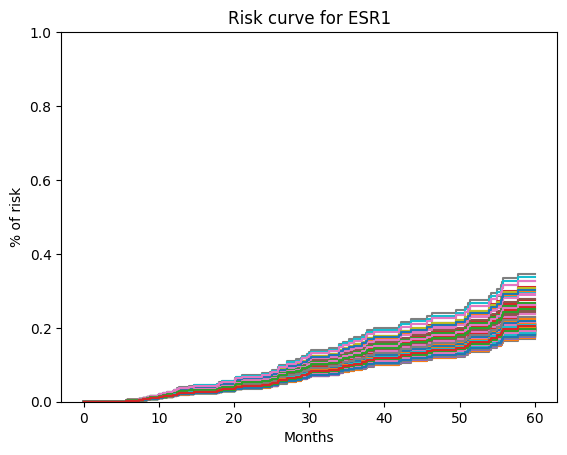

In [42]:
clean_mRNA_df = pp.eliminate_zero_genes(df_mRNA_raw_data, "Hugo_Symbol")

X_ESR1, Y_surv_ESR17, df_gene_merged_ESR1 = split_data_time_months(clean_mRNA_df,df_clinical_data, "ESR1", 60)
X_train_ESR1, X_test_ESR1, Y_train_ESR1, Y_test_ESR1 = train_test_split(
    X_ESR1, Y_surv_ESR17, train_size=0.80, test_size=0.20, random_state=42
)
betas_MKI67, chp_predict_ESR1, survival_curve_ESR1, risk_curve_ESR1 = Cox_regression(X_train=X_train_ESR1, 
                                                                                     Y_train=Y_train_ESR1, X_test=X_test_ESR1, draw_plot=True, title="ESR1")

In [44]:
df_life_ESR1 = df_gene_merged_ESR1[["expression", "event", "Overall Survival (Months)"]].copy()
df_life_ESR1["expression"] = pd.to_numeric(df_life_ESR1["expression"], errors="coerce")
df_life_ESR1["Overall Survival (Months)"] = pd.to_numeric(df_life_ESR1["Overall Survival (Months)"], errors="coerce")
df_life_ESR1 = df_life_ESR1.dropna(subset=["expression", "event", "Overall Survival (Months)"])
df_life_ESR1["time_60"] = np.minimum(df_life_ESR1["Overall Survival (Months)"], 60)
df_life_ESR1["event_60"] = df_life_ESR1["event"].copy()
df_life_ESR1.loc[df_life_ESR1["Overall Survival (Months)"] > 60, "event_60"] = False
df_life_ESR1_cox = df_life_ESR1[["expression", "time_60", "event_60"]].copy()
p_value_ESR1 = p_values_Cox_regression(
    df_life_ESR1_cox,
    event_col="event_60",
    duration_col="time_60"
)

p_value_ESR1

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
expression,-0.053146,0.948241,0.033812,-0.119417,0.013125,0.887438,1.013211,0.0,-1.571805,0.115996,3.107855


In [45]:
thr = df_gene_merged_ESR1["expression"].median()
low_group = df_gene_merged_ESR1[df_gene_merged_ESR1["expression"] < thr]
high_group = df_gene_merged_ESR1[df_gene_merged_ESR1["expression"] >= thr]

results = logrank_test(
        durations_A=low_group["time_60"],
        durations_B=high_group["time_60"],
        event_observed_A=low_group["event_60"],
        event_observed_B=high_group["event_60"]
    )
print(results)

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           0.03 0.87      0.20


Genes before Treshold: 818
count     818.000000
mean     2911.273839
std       351.415192
min         0.000000
25%      2709.250000
50%      2866.500000
75%      3078.500000
max      4575.000000
dtype: float64
Threshold (>80% zeros): 16352 samples
After the treshold: 818


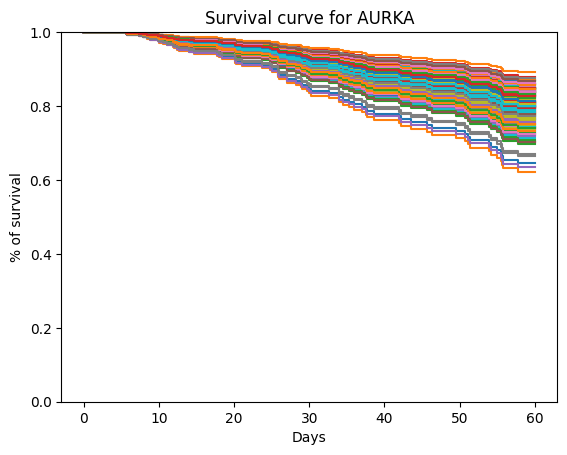

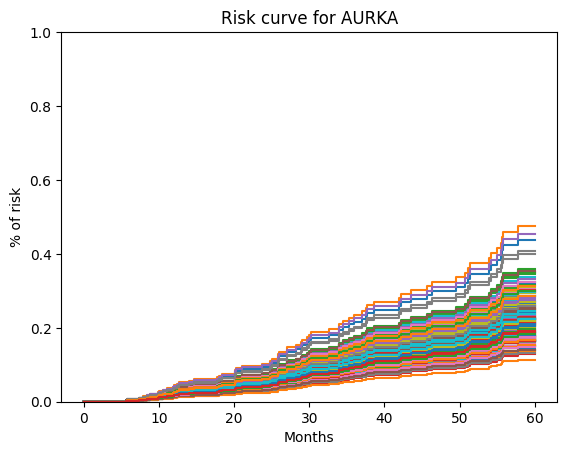

In [46]:
clean_mRNA_df = pp.eliminate_zero_genes(df_mRNA_raw_data, "Hugo_Symbol")

X_AURKA, Y_surv_AURKA, df_gene_merged_AURKA = split_data_time_months(clean_mRNA_df,df_clinical_data, "AURKA", 60)
X_train_AURKA, X_test_AURKA, Y_train_AURKA, Y_test_ESR1 = train_test_split(
    X_AURKA, Y_surv_AURKA, train_size=0.80, test_size=0.20, random_state=42
)
betas_AURKA, chp_predict_AURKA, survival_curve_AURKA, risk_curve_AURKA = Cox_regression(
    X_train=X_train_AURKA, Y_train=Y_train_AURKA, X_test=X_test_AURKA, draw_plot=True, title="AURKA"
)

In [47]:
df_life_AURKA = df_gene_merged_AURKA[["expression", "event", "Overall Survival (Months)"]].copy()
df_life_AURKA["expression"] = pd.to_numeric(df_life_AURKA["expression"], errors="coerce")
df_life_AURKA["Overall Survival (Months)"] = pd.to_numeric(df_life_AURKA["Overall Survival (Months)"], errors="coerce")
df_life_AURKA = df_life_AURKA.dropna(subset=["expression", "event", "Overall Survival (Months)"])
df_life_AURKA["time_60"] = np.minimum(df_life_AURKA["Overall Survival (Months)"], 60)
df_life_AURKA["event_60"] = df_life_AURKA["event"].copy()
df_life_AURKA.loc[df_life_AURKA["Overall Survival (Months)"] > 60, "event_60"] = False
df_life_AURKA_cox = df_life_AURKA[["expression", "time_60", "event_60"]].copy()
p_value_AURKA = p_values_Cox_regression(
    df_life_AURKA_cox,
    event_col="event_60",
    duration_col="time_60"
)
#Outcome y endpoint
p_value_AURKA

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
expression,0.18522,1.203483,0.091022,0.00682,0.363619,1.006844,1.438526,0.0,2.034895,0.041861,4.578235


In [48]:
thr = df_gene_merged_AURKA["expression"].median()
low_group = df_gene_merged_AURKA[df_gene_merged_AURKA["expression"] < thr]
high_group = df_gene_merged_AURKA[df_gene_merged_AURKA["expression"] >= thr]

results = logrank_test(
        durations_A=low_group["time_60"],
        durations_B=high_group["time_60"],
        event_observed_A=low_group["event_60"],
        event_observed_B=high_group["event_60"]
    )
print(results)

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           4.39 0.04      4.79


Genes before Treshold: 818
count     818.000000
mean     2911.273839
std       351.415192
min         0.000000
25%      2709.250000
50%      2866.500000
75%      3078.500000
max      4575.000000
dtype: float64
Threshold (>80% zeros): 16352 samples
After the treshold: 818


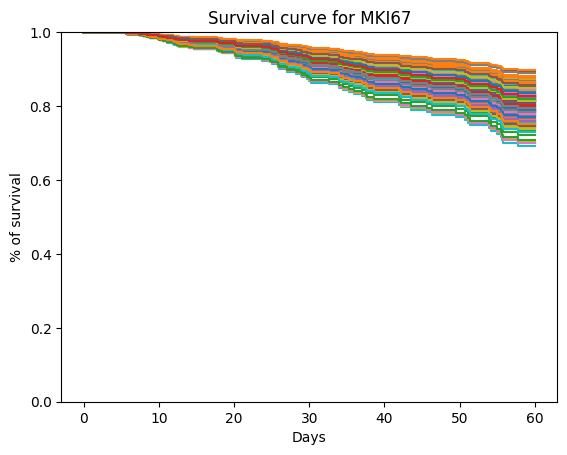

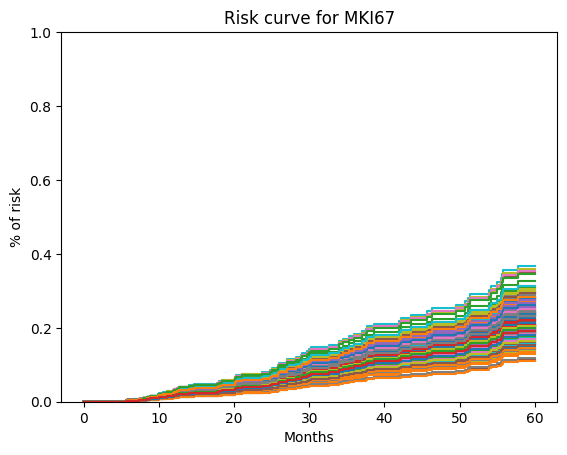

In [50]:
clean_mRNA_df = pp.eliminate_zero_genes(df_mRNA_raw_data, "Hugo_Symbol")

X_MKI67, Y_surv_MKI67, df_gene_merged_MKI67 = split_data_time_months(clean_mRNA_df,df_clinical_data, "MKI67", 60)
X_train_MKI67, X_test_MKI67, Y_train_MKI67, Y_test_MKI67 = train_test_split(
    X_MKI67, Y_surv_MKI67, train_size=0.80, test_size=0.20, random_state=42
)
betas_MKI67, chp_predict_MKI67, survival_curve_MKI67, risk_curve_MKI67 = Cox_regression(
    X_train=X_train_MKI67, Y_train=Y_train_MKI67, X_test=X_test_MKI67, draw_plot=True, title="MKI67"
)

In [51]:
df_life_MKI67 = df_gene_merged_MKI67[["expression", "event", "Overall Survival (Months)"]].copy()
df_life_MKI67["expression"] = pd.to_numeric(df_life_MKI67["expression"], errors="coerce")
df_life_MKI67["Overall Survival (Months)"] = pd.to_numeric(df_life_MKI67["Overall Survival (Months)"], errors="coerce")
df_life_MKI67 = df_life_MKI67.dropna(subset=["expression", "event", "Overall Survival (Months)"])
df_life_MKI67["time_60"] = np.minimum(df_life_MKI67["Overall Survival (Months)"], 60)
df_life_MKI67["event_60"] = df_life_MKI67["event"].copy()
df_life_MKI67.loc[df_life_MKI67["Overall Survival (Months)"] > 60, "event_60"] = False
df_life_MKI67_cox = df_life_MKI67[["expression", "time_60", "event_60"]].copy()
p_value_MKI67 = p_values_Cox_regression(
    df_life_MKI67_cox,
    event_col="event_60",
    duration_col="time_60"
)

p_value_MKI67

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
expression,0.184406,1.202504,0.088091,0.011751,0.357061,1.011821,1.429123,0.0,2.093365,0.036317,4.783227


In [52]:
thr = df_gene_merged_MKI67["expression"].median()
low_group = df_gene_merged_MKI67[df_gene_merged_MKI67["expression"] < thr]
high_group = df_gene_merged_MKI67[df_gene_merged_MKI67["expression"] >= thr]

results = logrank_test(
        durations_A=low_group["time_60"],
        durations_B=high_group["time_60"],
        event_observed_A=low_group["event_60"],
        event_observed_B=high_group["event_60"]
    )
print(results)

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           3.97 0.05      4.43


<font size="4">GroupKFold for all the genes</font>

In [58]:
#GroupKFold
group_k_fold = GroupKFold(n_splits=10)
group_k_fold.get_n_splits()
df_merged = pp.merge_datasets(df_clinical_data, clean_mRNA_df)
expressions_genes_cols = df_merged.iloc[1:20441].sample(5, axis="columns")



In [59]:
cols = ["Sample ID","Tumor-Cancer", "Overall Survival Status", "Overall Survival (Months)"] + list(expressions_genes_cols)

comparation_df = df_merged.loc[
    df_merged["Tumor-Cancer"].isin(["Luminal A", "Luminal B", "TNBC", "HER2-enriched"]),
    cols
]

comparation_df = pp.eliminate_zero_genes(comparation_df, "Tumor-Cancer", threshold=0.8)


Genes before Treshold: 8
count      8.000000
mean      24.875000
std       46.387922
min        0.000000
25%        0.000000
50%        5.000000
75%       25.250000
max      136.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 8


In [60]:
status = comparation_df["Overall Survival Status"].astype(str).str.strip()

comparation_df["event"] = status.str.contains("DECEASED", na=False)

comparation_df = comparation_df.dropna(subset=["Overall Survival (Months)"])

groups = comparation_df["Sample ID"]
comparation_df = comparation_df.drop(columns="Sample ID")

X = comparation_df.iloc[:, 3:-1]

Y = Surv.from_dataframe(
    event="event",
    time="Overall Survival (Months)",
    data=comparation_df
)

for i, (train_index, test_index) in enumerate(group_k_fold.split(X, Y, groups=groups)):
    print(f"Fold {i}:")
    X_train = X.iloc[train_index]
    Y_train = Y[train_index]
    
    X_test = X.iloc[test_index]
    betas, chp_predict, survival_curve, risk_curve = Cox_regression(X_train,
                                                                    Y_train,
                                                                    X_test,
                                                                    draw_plot=False
                                                                    ) 
    
    
    #Lista de significativos , intento con todos, MultiVariante -> Le añado unos cuantos 
    if i > 2:
        break

Fold 0:
Fold 1:
Fold 2:
Fold 3:


In [61]:
print(betas)
print(chp_predict)
print(survival_curve)
print(risk_curve)

           beta
4539  -0.012690
6730  -0.007401
13462  0.002128
9923   0.000046
1123   0.001627
[-0.72423686 -1.6894616  -0.29578918 -0.35913268 -0.39197012 -0.31173853
 -0.69764948 -0.7971738  -0.34800536 -0.5947488  -0.19285082 -0.81216819
 -1.04133508 -0.49297211 -1.0136877  -1.15011486 -0.14460334 -1.42535468
 -0.62076704 -0.47463869 -0.05235905 -0.17897151 -0.49245256 -0.68142642
 -2.1869937  -2.90611899 -0.54907754 -1.01144071 -0.77950026 -0.32604347
 -0.18116218 -0.31289649 -0.43809172 -0.45178515 -0.33858628 -0.97897927
 -0.24557069 -0.52365508 -0.42802025 -0.34008621 -0.25523729 -0.40913782
 -0.03749067 -1.14274174 -0.52867922 -1.14938007 -0.36137618 -0.55909134
 -0.49548462 -0.98759647 -0.24172579 -1.48669489]
[StepFunction(x=array([  0.        ,   0.33      ,   0.36      ,   0.99      ,
          1.02      ,   1.71      ,   2.5       ,   2.56      ,
          2.76      ,   3.22      ,   4.4       ,   5.19      ,
          5.58      ,   5.65      ,   5.72      ,   5.85      ,